In [1]:
#  !uv pip install git+https://github.com/daviddavo/lightfm

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict, Any

import scipy.sparse as sp
from scipy.sparse import coo_matrix

from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Установим seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR=r'data/books'

In [8]:
print("Загрузка данных...")
ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
books = pd.read_csv(os.path.join(DATA_DIR, "books.csv"))
to_read = pd.read_csv(os.path.join(DATA_DIR, "to_read.csv"))
tags = pd.read_csv(os.path.join(DATA_DIR, "tags.csv"))
book_tags = pd.read_csv(os.path.join(DATA_DIR, "book_tags.csv"))


initial_len = len(ratings)
ratings = ratings.drop_duplicates(subset=['user_id', 'book_id'], keep='last')
print(f"Удалено дубликатов: {initial_len - len(ratings)}")

train_ratings, test_ratings = train_test_split(
    ratings, test_size=0.2, random_state=RANDOM_STATE
)

all_users = set(ratings['user_id']).union(set(to_read['user_id']))
all_books = set(ratings['book_id'])\
            .union(set(books['book_id']))\
            .union(set(to_read['book_id']))

# Инициализируем и обучаем маппинг Dataset
dataset = Dataset()
dataset.fit(
    users=all_users,
    items=all_books
)

num_users, num_items = dataset.interactions_shape()
print(f"Построена матрица: {num_users} пользователей, {num_items} книг.")

train_interactions, train_weights = dataset.build_interactions(
    ((row['user_id'], row['book_id'], row['rating']) for _, row in train_ratings.iterrows())
)

test_interactions, test_weights = dataset.build_interactions(
    ((row['user_id'], row['book_id'], row['rating']) for _, row in test_ratings.iterrows())
)
print("Матрицы успешно построены без пересечений!")

Загрузка данных...
Удалено дубликатов: 2278
Построена матрица: 53424 пользователей, 19188 книг.
Матрицы успешно построены без пересечений!


In [9]:
# Очищаем данные
books['original_publication_year'] = books['original_publication_year'].fillna(-1).astype(int).astype(str)
books['authors'] = books['authors'].fillna('Unknown')

# Подготовка генератора признаков
def get_book_features(books_df: pd.DataFrame) -> List[str]:
    """Собирает все уникальные фичи книг для fit."""
    features = set()
    for _, row in books_df.iterrows():
        features.add(f"author:{row['authors']}")
        features.add(f"year:{row['original_publication_year']}")
    return list(features)

# Добавляем признаки в датасет
dataset.fit_partial(items=(x for x in books['book_id']), 
                    item_features=get_book_features(books))

# Строим item_features
def build_item_features_generator(books_df: pd.DataFrame):
    for _, row in books_df.iterrows():
        features = [
            f"author:{row['authors']}",
            f"year:{row['original_publication_year']}"
        ]
        yield (row['book_id'], features)

item_features = dataset.build_item_features(build_item_features_generator(books))
print(f"Размерность item_features: {item_features.shape}") # [n_items, n_items + n_features]

Размерность item_features: (19188, 24146)


In [10]:
# Инициализация модели
# loss='warp' идеален для неявного фидбека и ранжирования
model = LightFM(loss='warp', no_components=32, random_state=RANDOM_STATE)

print("Обучение гибридной модели...")
model.fit(
    interactions=train_interactions,
    item_features=item_features,
    epochs=30,
    num_threads=1
)

Обучение гибридной модели...


In [11]:
print("Подготовка сэмплов для быстрой оценки...")

train_csr = train_interactions.tocsr()
test_csr = test_interactions.tocsr()

NUM_EVAL_USERS = 1500

train_sample = train_csr.copy()
test_sample = test_csr.copy()

train_sample.data[train_sample.indptr[NUM_EVAL_USERS]:] = 0
train_sample.eliminate_zeros()

test_sample.data[test_sample.indptr[NUM_EVAL_USERS]:] = 0
test_sample.eliminate_zeros()

print("Оценка модели на подвыборке пользователей...")

train_precision = precision_at_k(model, train_sample, item_features=item_features, k=10, num_threads=1).mean()
test_precision = precision_at_k(model, test_sample, train_sample, item_features=item_features, k=10, num_threads=1).mean()

train_auc = auc_score(model, train_sample, item_features=item_features, num_threads=1).mean()
test_auc = auc_score(model, test_sample, train_sample, item_features=item_features, num_threads=1).mean()

print(f"Train Precision@10: {train_precision:.4f} | Test Precision@10: {test_precision:.4f}")
print(f"Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")


user_id_raw = 1
user_mapping, _, item_mapping, _ = dataset.mapping()
user_id_internal = user_mapping[user_id_raw]

item_ids_internal = np.arange(num_items)
predictions = model.predict(user_id_internal, item_ids_internal, item_features=item_features)

top_items_internal = np.argsort(-predictions)[:10]
inv_item_mapping = {v: k for k, v in item_mapping.items()}
top_items_raw =[inv_item_mapping[i] for i in top_items_internal]

print(f"\nТоп-10 рекомендаций для пользователя {user_id_raw}:")
print(books[books['book_id'].isin(top_items_raw)][['title', 'authors']])

Подготовка сэмплов для быстрой оценки...
Оценка модели на подвыборке пользователей...
Train Precision@10: 0.2436 | Test Precision@10: 0.0338
Train AUC: 0.9947 | Test AUC: 0.9502

Топ-10 рекомендаций для пользователя 1:
                 title                                         authors
6552  The Good Soldier  Ford Madox Ford, Kenneth Womack, William Baker


In [12]:
import random

def random_search_lightfm(train_interactions, train_sample, test_sample, item_features, num_iters=10):
    best_score = 0
    best_params = {}
    best_model = None
    
    print("Начало Random Search...")
    for i in range(num_iters):
        params = {
            'no_components': random.choice([16, 32, 64]),
            'learning_rate': np.random.exponential(0.05) + 0.01,
            'item_alpha': random.choice([0.0, 1e-5, 1e-4, 1e-3, 0.01]),
            'user_alpha': random.choice([0.0, 1e-5, 1e-4, 1e-3, 0.01]),
            'loss': random.choice(['warp', 'bpr'])
        }
        
        model_rs = LightFM(**params, random_state=RANDOM_STATE)
        model_rs.fit(train_interactions, item_features=item_features, epochs=10, num_threads=1)
        

        score = precision_at_k(
            model_rs, 
            test_sample, 
            train_interactions=train_sample, 
            item_features=item_features, 
            k=10, 
            num_threads=1
        ).mean()
        
        print(f"Iter {i+1}/{num_iters} | Precision@10: {score:.4f} | Params: {params}")
        
        if score > best_score:
            best_score = score
            best_params = params
            best_model = model_rs
            
    print(f"\nЛучший скор на валидации: {best_score:.4f}")
    print(f"Лучшие параметры: {best_params}")
    return best_model, best_params


best_model, best_params = random_search_lightfm(
    train_interactions=train_interactions, 
    train_sample=train_sample, 
    test_sample=test_sample, 
    item_features=item_features, 
    num_iters=5
)

Начало Random Search...
Iter 1/5 | Precision@10: 0.0004 | Params: {'no_components': 32, 'learning_rate': 0.033463404498842955, 'item_alpha': 0.01, 'user_alpha': 0.001, 'loss': 'bpr'}
Iter 2/5 | Precision@10: 0.0003 | Params: {'no_components': 64, 'learning_rate': 0.16050607154587607, 'item_alpha': 1e-05, 'user_alpha': 0.001, 'loss': 'warp'}
Iter 3/5 | Precision@10: 0.0007 | Params: {'no_components': 32, 'learning_rate': 0.07583728467727247, 'item_alpha': 0.0, 'user_alpha': 0.0001, 'loss': 'bpr'}
Iter 4/5 | Precision@10: 0.0004 | Params: {'no_components': 16, 'learning_rate': 0.05564712768879767, 'item_alpha': 1e-05, 'user_alpha': 0.001, 'loss': 'bpr'}
Iter 5/5 | Precision@10: 0.0134 | Params: {'no_components': 64, 'learning_rate': 0.018481243523117315, 'item_alpha': 0.0001, 'user_alpha': 1e-05, 'loss': 'warp'}

Лучший скор на валидации: 0.0134
Лучшие параметры: {'no_components': 64, 'learning_rate': 0.018481243523117315, 'item_alpha': 0.0001, 'user_alpha': 1e-05, 'loss': 'warp'}


In [ ]:
# 1. Объединяем рейтинги и to_read
to_read_df = to_read.copy()
to_read_df['rating'] = 1  # Задаем вес 1 для неявного фидбека (добавление в "хочу прочитать")

ratings_df = ratings.copy()
# Явный фидбек (рейтинги) оставляем как есть, их веса от 1 до 5

combined_interactions = pd.concat([
    ratings_df[['user_id', 'book_id', 'rating']], 
    to_read_df[['user_id', 'book_id', 'rating']]
])

# 2. Обогащаем книги тегами
book_tags_merged = book_tags.merge(tags, on='tag_id')

col_books = 'goodreads_book_id' if 'goodreads_book_id' in books.columns else 'book_id'
col_tags = 'goodreads_book_id' if 'goodreads_book_id' in book_tags_merged.columns else 'book_id'

print(f"Слияние: таблица books (по '{col_books}') + таблица tags (по '{col_tags}')")

# Группируем теги в списки по каждой книге
tags_per_book = book_tags_merged.groupby(col_tags)['tag_name'].apply(list).reset_index()

# Сливаем (Left Join, чтобы не потерять книги без тегов)
books_extended = books.merge(tags_per_book, left_on=col_books, right_on=col_tags, how='left')

# Если тегов нет, ставим пустой список вместо NaN
books_extended['tag_name'] = books_extended['tag_name'].apply(lambda x: x if isinstance(x, list) else[])

# 3. Пересобираем Dataset LightFM
dataset_ext = Dataset()

all_ext_users = set(combined_interactions['user_id'])
all_ext_books = set(combined_interactions['book_id']).union(set(books_extended['book_id']))

dataset_ext.fit(
    users=all_ext_users,
    items=all_ext_books
)

def get_ext_features_generator(books_df):
    for _, row in books_df.iterrows():
        year = str(row.get('original_publication_year', -1))
        author = str(row.get('authors', 'Unknown'))
        
        features = [f"author:{author}", f"year:{year}"]
        # Берем топ-10 тегов (чтобы не раздувать матрицу признаков до бесконечности)
        for tag in row['tag_name'][:10]:
            features.append(f"tag:{tag}")
        yield (row['book_id'], features)

all_ext_features = set()
for _, row in books_extended.iterrows():
    year = str(row.get('original_publication_year', -1))
    author = str(row.get('authors', 'Unknown'))
    all_ext_features.add(f"author:{author}")
    all_ext_features.add(f"year:{year}")
    for tag in row['tag_name'][:10]:
        all_ext_features.add(f"tag:{tag}")

# Обучаем датасет на новых признаках
dataset_ext.fit_partial(items=all_ext_books, item_features=list(all_ext_features))

# Строим новую матрицу признаков
item_features_ext = dataset_ext.build_item_features(get_ext_features_generator(books_extended))

# Строим новые матрицы взаимодействий
inter_mat, weights_mat = dataset_ext.build_interactions(
    ((row['user_id'], row['book_id'], row['rating']) for _, row in combined_interactions.iterrows())
)

print(f"Успешно! Размер новой матрицы признаков (с тегами): {item_features_ext.shape}")

Слияние: таблица books (по 'book_id') + таблица tags (по 'goodreads_book_id')
Успешно! Размер новой матрицы признаков (с тегами): (19188, 26097)


In [28]:
print("Подготовка правильной матрицы взаимодействий (Синхронизация маппинга)...")
train_interactions_ext, _ = dataset_ext.build_interactions(
    ((row['user_id'], row['book_id'], row['rating']) for _, row in train_ratings.iterrows())
)

print("Обучение базовых моделей для ансамбля...")
# 1. Обучаем чисто Коллаборативную модель
model_cf = LightFM(loss='warp', no_components=32, random_state=RANDOM_STATE)
model_cf.fit(train_interactions_ext, epochs=10, num_threads=1) 

# 2. Обучаем Гибридную модель
model_hybrid = LightFM(loss='warp', no_components=32, random_state=RANDOM_STATE)
model_hybrid.fit(train_interactions_ext, item_features=item_features_ext, epochs=10, num_threads=1)


print("\nАнализ распределения популярности...")
book_counts = train_ratings['book_id'].value_counts()

pop_thresh = book_counts.quantile(0.8)  # Топ 20%
rare_thresh = book_counts.quantile(0.2) # Нижние 20%

popular_books_ids = book_counts[book_counts >= pop_thresh].index.tolist()
rare_books_ids = book_counts[book_counts <= rare_thresh].index.tolist()

print(f"Порог для 'Популярных': >= {int(pop_thresh)} оценок (таких книг: {len(popular_books_ids)})")
print(f"Порог для 'Редких': <= {int(rare_thresh)} оценок (таких книг: {len(rare_books_ids)})")



Подготовка правильной матрицы взаимодействий (Синхронизация маппинга)...
Обучение базовых моделей для ансамбля...

Анализ распределения популярности...
Порог для 'Популярных': >= 83 оценок (таких книг: 2148)
Порог для 'Редких': <= 75 оценок (таких книг: 2278)


In [29]:
user_id_raw = 2
user_mapping, _, item_mapping, _ = dataset_ext.mapping()
if user_id_raw in user_mapping:
    user_id_internal = user_mapping[user_id_raw]
    
    # ---------------------------------------------------------
    # ПАТТЕРН: INVENTORY FILTERING (Фильтрация каталога)
    # ---------------------------------------------------------
    # 1. Смотрим, какие книги РЕАЛЬНО есть в файле books.csv
    available_book_ids = books['book_id'].unique()
    
    # 2. Переводим их во внутренние ID модели (игнорируем те, что модель не знает)
    available_internal_ids =[]
    for bid in available_book_ids:
        if bid in item_mapping:
            available_internal_ids.append(item_mapping[bid])
            
    available_internal_ids = np.array(available_internal_ids)
    print(f"Всего книг в истории: {dataset_ext.interactions_shape()[1]}")
    print(f"Книг 'в наличии' (в books.csv): {len(available_internal_ids)}")
    
    # 3. Делаем предсказания ТОЛЬКО для доступных книг!
    pred_cf = model_cf.predict(user_id_internal, available_internal_ids)
    pred_hybrid = model_hybrid.predict(user_id_internal, available_internal_ids, item_features=item_features_ext)
    
    # Взвешенное среднее (Ансамбль)
    alpha = 0.5 
    pred_ensemble = (alpha * pred_cf) + ((1 - alpha) * pred_hybrid)
    
    # 4. Сортируем и берем Топ-5 индексов из НАШЕГО массива
    top_indices = np.argsort(-pred_ensemble)[:5]
    top_internal_ids = available_internal_ids[top_indices] # Получаем внутренние ID
    
    # 5. Возвращаем внешние ID и смело ищем в таблице
    inv_item_mapping = {v: k for k, v in item_mapping.items()}
    top_items_raw =[inv_item_mapping[i] for i in top_internal_ids]
    
    print(f"\nТоп-5 рекомендаций ансамбля для пользователя {user_id_raw}:")
    recommended_books = books[books['book_id'].isin(top_items_raw)][['title', 'authors']]
    print(recommended_books)
else:
    print(f"Пользователь {user_id_raw} не найден в обучающей выборке.")

Всего книг в истории: 19188
Книг 'в наличии' (в books.csv): 10000

Топ-5 рекомендаций ансамбля для пользователя 2:
                                                  title  \
314                                Who Moved My Cheese?   
390                                           The Lorax   
491             Speaker for the Dead (Ender's Saga, #2)   
5826           The First Four Years  (Little House, #9)   
6425  Loving What Is: Four Questions That Can Change...   

                                    authors  
314   Spencer Johnson, Kenneth H. Blanchard  
390                               Dr. Seuss  
491                        Orson Scott Card  
5826   Laura Ingalls Wilder, Garth Williams  
6425          Byron Katie, Stephen Mitchell  


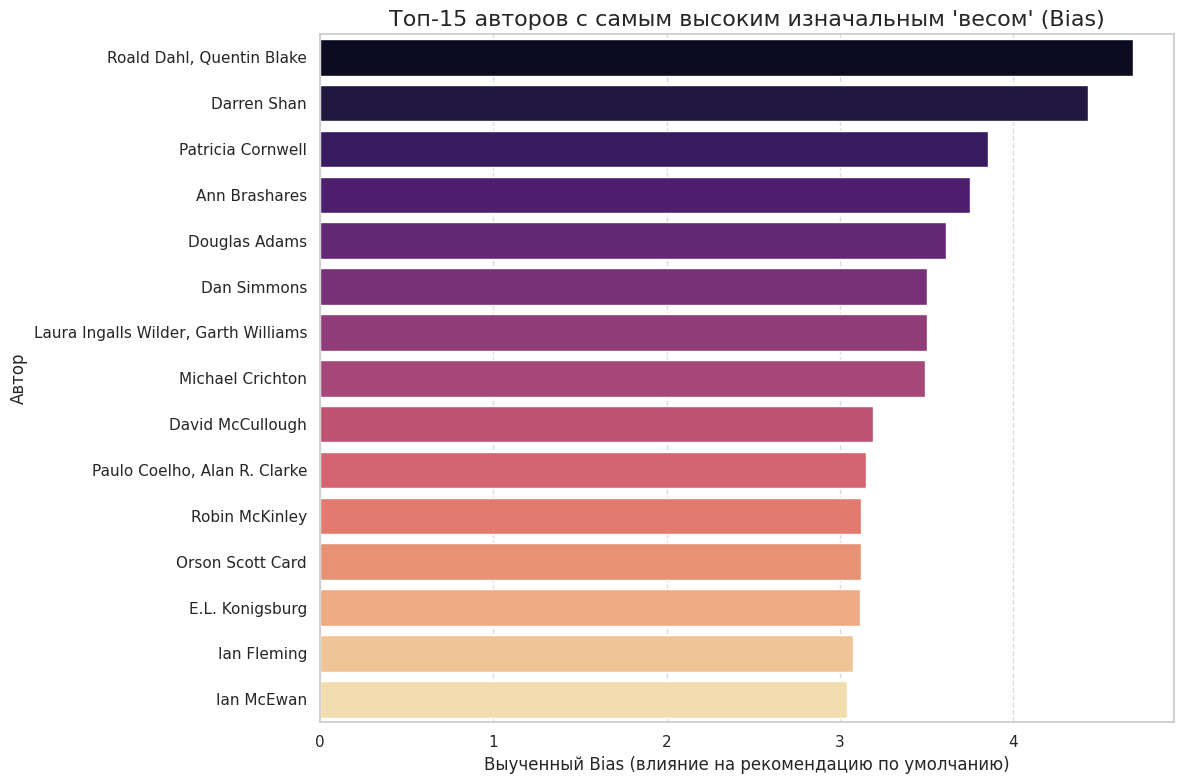

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

item_biases, item_embeddings = model_hybrid.get_item_representations()

_, _, _, item_feature_mapping = dataset_ext.mapping()

inv_feature_mapping = {v: k for k, v in item_feature_mapping.items()}

df_features = pd.DataFrame({
    'feature_name':[inv_feature_mapping[i] for i in range(len(item_biases))],
    'bias': item_biases
})

df_authors = df_features[df_features['feature_name'].astype(str).str.startswith('author:')].copy()

df_authors['feature_name'] = df_authors['feature_name'].apply(lambda x: str(x).replace('author:', ''))

top_authors = df_authors.sort_values('bias', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='bias', y='feature_name', hue = 'feature_name', data=top_authors, palette='magma')

plt.title("Топ-15 авторов с самым высоким изначальным 'весом' (Bias)", fontsize=16)
plt.xlabel("Выученный Bias (влияние на рекомендацию по умолчанию)", fontsize=12)
plt.ylabel("Автор", fontsize=12)

# Добавляем сетку для удобства чтения
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import scipy.sparse as sp
from lightfm.evaluation import precision_at_k, auc_score


test_interactions_ext, _ = dataset_ext.build_interactions(
    ((row['user_id'], row['book_id'], row['rating']) for _, row in test_ratings.iterrows())
)

print("Сэмплируем пользователей для быстрой оффлайн-оценки...")
NUM_EVAL_USERS = 1500

# Переводим в формат CSR
train_sample_ext = train_interactions_ext.tocsr().copy()
test_sample_ext = test_interactions_ext.tocsr().copy()

train_sample_ext.data[train_sample_ext.indptr[NUM_EVAL_USERS]:] = 0
train_sample_ext.eliminate_zeros()

test_sample_ext.data[test_sample_ext.indptr[NUM_EVAL_USERS]:] = 0
test_sample_ext.eliminate_zeros()

print("Считаем метрики для 'Только коллаборативной' модели...")
cf_precision = precision_at_k(
    model_cf, 
    test_sample_ext, 
    train_interactions=train_sample_ext, 
    k=10, 
    num_threads=1
).mean()

cf_auc = auc_score(
    model_cf, 
    test_sample_ext, 
    train_interactions=train_sample_ext, 
    num_threads=1
).mean()

print("Считаем метрики для 'Гибридной' модели...")
hybrid_precision = precision_at_k(
    model_hybrid, 
    test_sample_ext, 
    train_interactions=train_sample_ext, 
    item_features=item_features_ext, 
    k=10, 
    num_threads=1
).mean()

hybrid_auc = auc_score(
    model_hybrid, 
    test_sample_ext, 
    train_interactions=train_sample_ext, 
    item_features=item_features_ext, 
    num_threads=1
).mean()


results_df = pd.DataFrame({
    'Модель':['Чистая Коллаборативная (CF)', 'Гибридная (CF + Content)'],
    'Test Precision@10':[cf_precision, hybrid_precision],
    'Test AUC': [cf_auc, hybrid_auc]
})

print("\n" + "="*50)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (ОФФЛАЙН МЕТРИКИ)")
print("="*50)
display(results_df)


Сэмплируем пользователей для быстрой оффлайн-оценки...
Считаем метрики для 'Только коллаборативной' модели...
Считаем метрики для 'Гибридной' модели...

ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ (ОФФЛАЙН МЕТРИКИ)


,Модель,Test Precision@10,Test AUC
0,Чистая Коллаборативная (CF),0.028772,0.948273
1,Гибридная (CF + Content),0.026053,0.935977
